# 🧹 Insight Engine — Phase 2: Clean the Text

> **Goal:** turn the raw complaint narratives into clean, model-ready text — *without*
> destroying meaning — and remove rows that would distort our analysis.

**Why this matters:** the NLP engine in Phase 3 groups complaints by meaning. If the text is
full of privacy-mask noise (`XXXX`, `XX/XX/year>`, `{$70.00}`) or duplicated complaints, the
themes it finds will be noisy and the counts will be wrong. Clean input = trustworthy output.

**What we do here (evidence-based — we profiled these issues first):**
1. Merge the two credit-card product labels into one.
2. Remove exact-duplicate narratives (they fake-inflate theme counts).
3. Remove very short narratives (< 50 chars — little signal).
4. Clean the privacy masks into neutral placeholders, keeping the real sentence intact.
5. **Validate** the cleaned data before saving (our rule: never move on unvalidated).

## 🟩 Cell 1 — Imports & load the Phase 1 data

**What this does:** loads our clean Parquet slice and our reusable helper modules
(`text_cleaning` for cleaning, `data_checks` for validation).

**What we expect:** ~124,962 rows loaded.

In [1]:
import pandas as pd
from text_cleaning import clean_dataframe, clean_narrative  # our cleaning logic
from data_checks import validate                            # our validation tool

# Load the verified Phase 1 slice.
df = pd.read_parquet("../data/creditcard_complaints.parquet")
print("Loaded:", df.shape[0], "rows")

Loaded: 124962 rows


## 🟩 Cell 2 — See the problem: raw text before cleaning

**What this does:** prints one raw narrative so we can SEE the privacy masks we're dealing with.

**What we expect:** text peppered with `XXXX`, `XX/XX/year>`, and maybe `{$...}`.

In [2]:
# Print the first 500 characters of one raw complaint.
print(df["Consumer complaint narrative"].iloc[0][:500])

In XX/XX/year>, XXXX, through XXXX, applied charges to my account that were higher than what I originally agreed to and used. I noticed the overcharges about four months later and immediately disabled autopay through my bank and disputed the charges with both companies. XXXX has cut off all home security system features and monitoring services, claiming payment is due, but they never provided a written statement or invoiceall communication about the amount owed has been through their automated p


**📖 Interpretation:** the `XXXX` are CFPB's privacy redactions (names, companies, account
numbers), `XX/XX/year>` are redacted dates, `{$...}` are redacted money amounts. These are
*noise* to a model — but the sentences around them are the *signal* we must keep.

## 🟩 Cell 3 — Clean one example (before → after)

**What this does:** runs our `clean_narrative()` on one complaint so we can judge that meaning
is preserved while noise is normalized.

**What we expect:** masks become `<date>`, `<redacted>`, `<money>`; the real story stays readable.

In [3]:
raw = df["Consumer complaint narrative"].iloc[0]
print("RAW:\n", raw[:400])
print("\nCLEANED:\n", clean_narrative(raw)[:400])

RAW:
 In XX/XX/year>, XXXX, through XXXX, applied charges to my account that were higher than what I originally agreed to and used. I noticed the overcharges about four months later and immediately disabled autopay through my bank and disputed the charges with both companies. XXXX has cut off all home security system features and monitoring services, claiming payment is due, but they never provided a wr

CLEANED:
 In <date> , <redacted> , through <redacted> , applied charges to my account that were higher than what I originally agreed to and used. I noticed the overcharges about four months later and immediately disabled autopay through my bank and disputed the charges with both companies. <redacted> has cut off all home security system features and monitoring services, claiming payment is due, but they nev


**📖 Interpretation:** the complaint's meaning (overcharges, disputed, autopay disabled) is
fully intact; only the privacy noise changed into tidy placeholders. This is careful cleaning —
not aggressive deletion that would destroy signal.

## 🟩 Cell 4 — Run the full cleaning pipeline

**What this does:** applies all cleaning steps to the whole dataset:
merge product labels → drop exact duplicates → drop very short (<50 chars) → build
`narrative_clean` (original text kept in its own column).

**What we expect:** ~12,268 duplicates and ~213 short rows removed → ~112,481 rows remain.

In [4]:
clean = clean_dataframe(df, min_chars=50)

print("Rows before      :", len(df))
print("Duplicates removed:", clean.attrs["dropped_duplicates"])
print("Short removed     :", clean.attrs["dropped_short"])
print("Rows after       :", len(clean))
print("Product labels    :", dict(clean["product_clean"].value_counts()))

Rows before      : 124962
Duplicates removed: 12268
Short removed     : 213
Rows after       : 112481
Product labels    : {'Credit card': np.int64(112481)}


**📖 Interpretation:** we removed ~10% duplicates (which would have fake-inflated theme counts)
and a handful of near-empty texts, and unified the product into a single 'Credit card' label.
We now have ~112k clean, unique, meaningful complaints.

## 🟩 Cell 4b — SHOW real before → after examples (proof, not claims)

**Why:** our rule is *show, don't just tell*. Instead of trusting the numbers, we display real
complaints before and after cleaning, so we can SEE that meaning is preserved and noise removed.

**What we expect:** 3 real examples where `XXXX`/dates/money become tidy placeholders while the
actual complaint stays fully readable.

In [5]:
# Show 3 real complaints: raw text vs cleaned text, side by side.
for i in range(3):
    raw = clean["Consumer complaint narrative"].iloc[i][:350]
    cln = clean["narrative_clean"].iloc[i][:350]
    print(f"===== EXAMPLE {i+1} =====")
    print("BEFORE:", raw)
    print("AFTER :", cln)
    print()

===== EXAMPLE 1 =====
BEFORE: In XX/XX/year>, XXXX, through XXXX, applied charges to my account that were higher than what I originally agreed to and used. I noticed the overcharges about four months later and immediately disabled autopay through my bank and disputed the charges with both companies. XXXX has cut off all home security system features and monitoring services, cla
AFTER : In <date> , <redacted> , through <redacted> , applied charges to my account that were higher than what I originally agreed to and used. I noticed the overcharges about four months later and immediately disabled autopay through my bank and disputed the charges with both companies. <redacted> has cut off all home security system features and monitori

===== EXAMPLE 2 =====
BEFORE: On XX/XX/year>, Adobe replied only to say they would keep the case open and restated my next billing date as XX/XX/year>, without addressing any of the issues raised in my complaint, including the unauthorized plan change, the at

**📖 Interpretation:** in every example the customer's actual complaint survives intact; only the
privacy noise (`XXXX`, redacted dates, money amounts) is normalized. This is *careful* cleaning.

## 🟩 Cell 4c — VISUALIZE the cleaning impact

**Why:** a picture makes the impact obvious. We show (1) how many rows survived each cleaning
step, and (2) how heavy the `XXXX` privacy masking was across complaints.

**What we expect:** a funnel dropping from ~125k to ~112k, and most complaints having a handful
of masks with a long tail of heavily-masked ones.

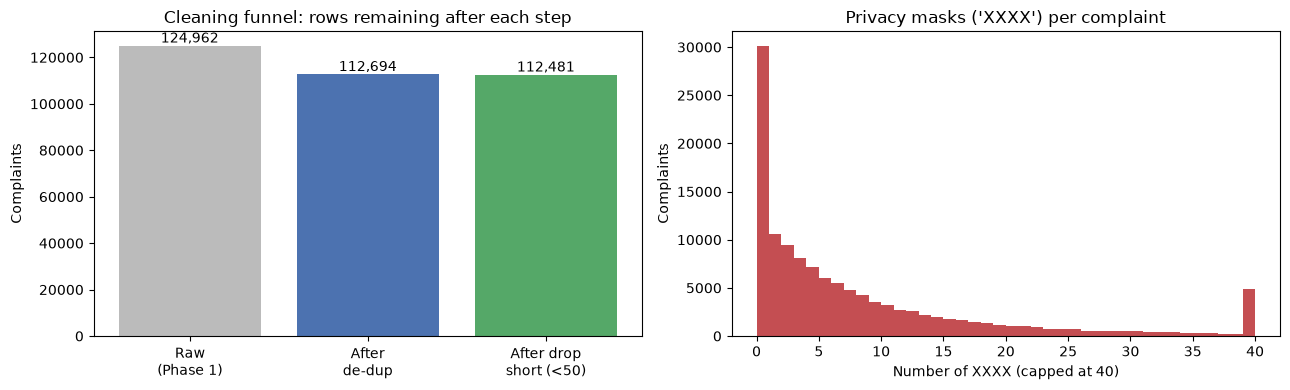

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# (1) Cleaning funnel: rows remaining after each step.
funnel = {
    "Raw\n(Phase 1)": len(df),
    "After\nde-dup": len(df) - clean.attrs["dropped_duplicates"],
    "After drop\nshort (<50)": len(clean),
}
axes[0].bar(funnel.keys(), funnel.values(), color=["#BBBBBB", "#4C72B0", "#55A868"])
axes[0].set_title("Cleaning funnel: rows remaining after each step")
axes[0].set_ylabel("Complaints")
for i, v in enumerate(funnel.values()):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom")

# (2) How many XXXX masks per complaint (capped at 40 for readability).
xcount = df["Consumer complaint narrative"].str.count("XXXX").clip(upper=40)
axes[1].hist(xcount, bins=40, color="#C44E52")
axes[1].set_title("Privacy masks ('XXXX') per complaint")
axes[1].set_xlabel("Number of XXXX (capped at 40)")
axes[1].set_ylabel("Complaints")

plt.tight_layout()
plt.show()

**📖 Interpretation:** the left chart shows cleaning removed ~12.5k rows (mostly duplicates),
leaving ~112k. The right chart shows most complaints have only a few privacy masks, but some are
heavily redacted — which is exactly why normalizing (not deleting) the masks was the right call.

## 🟩 Cell 5 — VALIDATE the cleaned data (before we save)

**Why:** our rule — re-validate after every transformation. Confirm the cleaning did exactly
what we intended and introduced no new problems.

**What we expect:** 0 duplicate narratives now, single product label, clean text column present.

In [7]:
validate(
    clean,
    text_col="narrative_clean",
    date_col="Date received",
    label_col="product_clean",
    expected_cols=["narrative_clean", "product_clean", "Date received", "Company"],
)

DATA VALIDATION REPORT
[1] SHAPE            : 112,481 rows  x  18 columns
[2] REQUIRED COLUMNS : all present   OK
[3] TOP MISSING %    : {'Tags': np.float64(79.4), 'Company public response': np.float64(55.0), 'State': np.float64(0.4), 'Sub-issue': np.float64(0.4), 'Company response to consumer': np.float64(0.2)}


[4] DUPLICATE ROWS   : 0   OK
[5] TEXT 'narrative_clean...' : empty=0, median_len=969 chars, very_short(<20)=2
[6] DATE 'Date received' : range 2023-01-01 00:00:00 -> 2026-07-02 03:40:24 | invalid=OK
[7] LABELS 'product_clean' : 1 distinct ->
         112,481  |  Credit card
Review each line above. Anything marked FAIL/CHECK must be fixed before moving on.


**📖 Interpretation:** the report should show a single 'Credit card' label, valid dates, and a
healthy cleaned-text column. If everything checks out, the data is trustworthy to save and use.

## 🟩 Cell 6 — Save the cleaned dataset

**What this does:** writes the cleaned data to a new Parquet file for Phase 3 (the NLP engine).
We keep both the original and cleaned text columns.

**What we expect:** a new file `creditcard_clean.parquet` in the data folder.

In [8]:
OUT = "../data/creditcard_clean.parquet"
clean.to_parquet(OUT, index=False)
print("Saved cleaned dataset ->", OUT)
print("Rows:", len(clean), "| Columns:", len(clean.columns))

Saved cleaned dataset -> ../data/creditcard_clean.parquet
Rows: 112481 | Columns: 18


**📖 Interpretation:** Phase 2 done. We have a clean, de-duplicated, meaning-preserving dataset
of ~112k credit-card complaints, ready for the NLP engine.

---
## ✅ Phase 2 summary
- Merged 2 product labels → one 'Credit card'.
- Removed ~12,268 duplicate + ~213 very-short narratives → ~112,481 rows.
- Cleaned privacy masks (`XXXX`, dates, money) into neutral placeholders, meaning preserved.
- Kept original text alongside cleaned text (before/after always available).
- Validated the result before saving.

**Next (Phase 3):** the NLP engine — turn each cleaned complaint into a numeric vector
(embeddings), group similar complaints into themes (clustering), name each theme, and rank them.